Font in use: Times New Roman
Saved: /Users/nandan/Desktop/CTCs/IBM/postselection_rate.png
Saved: /Users/nandan/Desktop/CTCs/IBM/postselection_rate.pdf


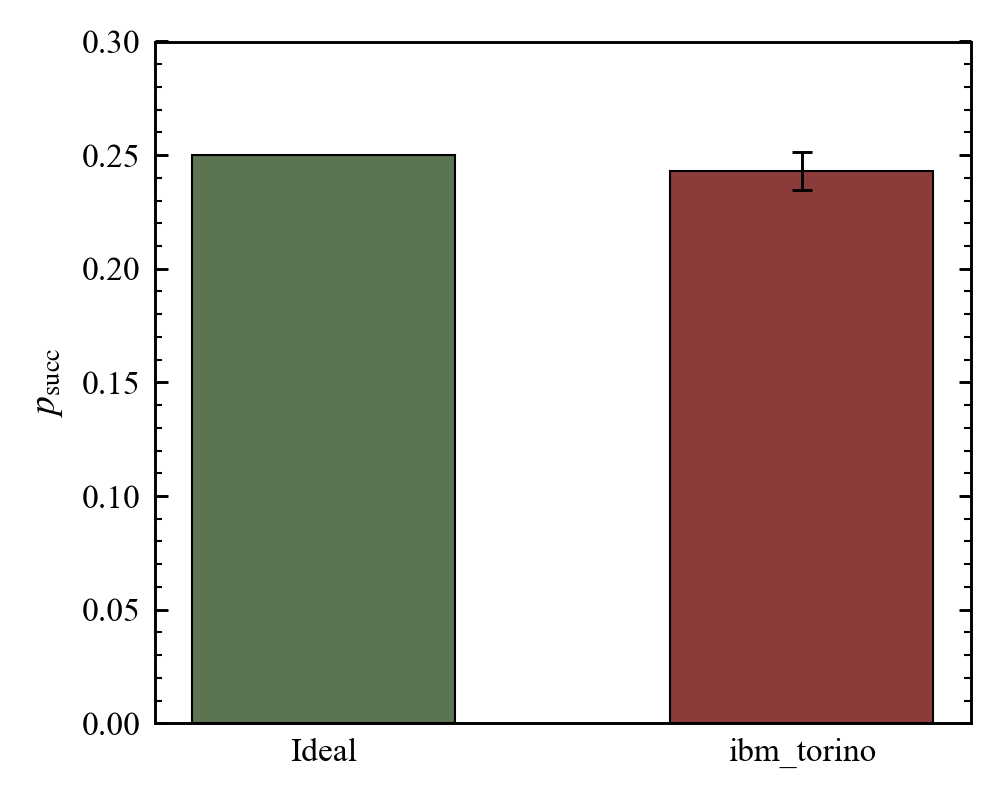

In [5]:
"""
PRL single-column bar chart: post-selection probability — Ideal vs Hardware.

Tweakables are grouped at the top.  Run:
    python postselection_rate.py

Outputs:
    postselection_rate.png  (600 dpi, for slides/previews)
    postselection_rate.pdf  (vector, for LaTeX/journal submission)

------------------------------------------------------------------
FONT NOTES
------------------------------------------------------------------
This script tries to use real Times New Roman if available on your
system; if not, it falls back to STIX Two Text (a Times look-alike
that ships with matplotlib).  Either way, the output looks like
Times — no DejaVu Serif silent fallback.

If you want to force real Times New Roman:
  - macOS / Windows: usually already installed; should be detected.
  - Linux: `sudo apt install msttcorefonts-installer ttf-mscorefonts-installer`
           then `rm -rf ~/.cache/matplotlib` to clear the font cache.
"""
import json
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
from matplotlib.ticker import MultipleLocator

# ============================================================
# Tweakable parameters
# ============================================================
INPUT_JSON  = "hardware_postselection_results.json"
OUT_BASE    = "/Users/nandan/Desktop/CTCs/IBM/postselection_rate"   # .png + .pdf appended

P_IDEAL     = 0.25                  # theoretical post-selection prob (1/4)
COLOR_IDEAL = "#5b7553"             # muted sage green
COLOR_HW    = "#8c3b3b"             # muted brick red
FIGSIZE_IN  = (3.375, 2.7)          # PRL single column = 3.375 in
SHOW_TITLE  = True                  # set False to push title into caption
# TITLE_TEXT  = "Post-selection rate"

# ============================================================
# Font selection: real Times if available, else STIX Two Text
# ============================================================
installed = {f.name for f in fm.fontManager.ttflist}
if "Times New Roman" in installed:
    SERIF_STACK = ["Times New Roman"]
    MATHTEXT_FS = "stix"             # closest mathtext match to Times
elif "Times" in installed:
    SERIF_STACK = ["Times"]
    MATHTEXT_FS = "stix"
else:
    # STIX Two Text is Times-like, designed for science, ships with matplotlib.
    SERIF_STACK = ["STIX Two Text", "STIXGeneral", "DejaVu Serif"]
    MATHTEXT_FS = "stix"

# ============================================================
# PRL-style rcParams
# ============================================================
mpl.rcParams.update({
    "font.family":         "serif",
    "font.serif":          SERIF_STACK,
    "mathtext.fontset":    MATHTEXT_FS,
    "font.size":           8,
    "axes.labelsize":      9,
    "axes.titlesize":      9,
    "xtick.labelsize":     8,
    "ytick.labelsize":     8,
    "axes.linewidth":      0.7,
    "xtick.major.width":   0.7,
    "ytick.major.width":   0.7,
    "xtick.minor.width":   0.5,
    "ytick.minor.width":   0.5,
    "xtick.major.size":    3.0,
    "ytick.major.size":    3.0,
    "xtick.minor.size":    1.6,
    "ytick.minor.size":    1.6,
    "xtick.direction":     "in",
    "ytick.direction":     "in",
    "xtick.top":           True,    # PRL: ticks on all four sides
    "ytick.right":         True,
    "axes.spines.top":     True,
    "axes.spines.right":   True,
    "pdf.fonttype":        42,      # editable text in PDF
    "ps.fonttype":         42,
})

# ============================================================
# Load data
# ============================================================
with open(INPUT_JSON) as f:
    data = json.load(f)

p_hw    = data["p_succ"]["estimate"]
ci_lo   = data["p_succ"]["ci_lo"]
ci_hi   = data["p_succ"]["ci_hi"]
nshots  = data["metadata"]["shots_per_basis"]
backend = data["metadata"]["backend"]

# Asymmetric error bar (distance from estimate)
yerr = np.array([[p_hw - ci_lo],
                 [ci_hi - p_hw]])

# ============================================================
# Figure
# ============================================================
fig, ax = plt.subplots(figsize=FIGSIZE_IN, dpi=300)

x = np.array([0, 1])
ax.bar(
    x, [P_IDEAL, p_hw],
    width=0.55,
    color=[COLOR_IDEAL, COLOR_HW],
    edgecolor="black",
    linewidth=0.5,
    zorder=3,
)

# 95% Clopper-Pearson CI on the hardware bar
ax.errorbar(
    x[1], p_hw, yerr=yerr,
    fmt="none", ecolor="black",
    elinewidth=0.7, capsize=2.5, capthick=0.7,
    zorder=4,
)

# ---- axes formatting ----
ax.set_xticks(x)
ax.set_xticklabels(["Ideal", backend])
ax.tick_params(axis="x", which="both", length=0)   # categorical: no x ticks
ax.set_ylabel(r"$p_{\mathrm{succ}}$", labelpad=4)

ax.set_ylim(0, 0.30)
ax.yaxis.set_major_locator(MultipleLocator(0.05))
ax.yaxis.set_minor_locator(MultipleLocator(0.01))

# if SHOW_TITLE:
#     ax.set_title(loc="center", fontsize=9, pad=6)

plt.tight_layout()

# ============================================================
# Save
# ============================================================
plt.savefig(f"{OUT_BASE}.png", dpi=600, bbox_inches="tight")
plt.savefig(f"{OUT_BASE}.pdf",            bbox_inches="tight")
print("Font in use:", mpl.rcParams["font.serif"][0])
print(f"Saved: {OUT_BASE}.png")
print(f"Saved: {OUT_BASE}.pdf")

Font in use: Times New Roman
Saved: /Users/nandan/Desktop/CTCs/IBM/pauli_expectations.png
Saved: /Users/nandan/Desktop/CTCs/IBM/pauli_expectations.pdf


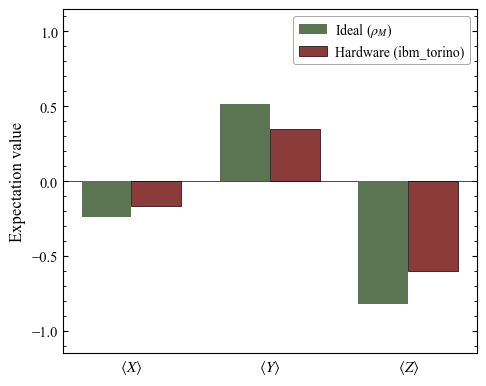

In [15]:
"""
PRX-style bar chart of Pauli expectation values: Ideal (rho_M) vs Hardware (ibm_torino).

Tweakables grouped at the top.  Run:
    python pauli_expectations.py

Outputs:
    pauli_expectations.png  (600 dpi)
    pauli_expectations.pdf  (vector, for LaTeX)

------------------------------------------------------------------
FONT NOTES (project standard)
------------------------------------------------------------------
Tries to use real Times New Roman if available; falls back to STIX
Two Text (a Times look-alike that ships with matplotlib).
Linux users may need: `sudo apt install msttcorefonts-installer`
followed by `rm -rf ~/.cache/matplotlib`.
"""
import json
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
from matplotlib.ticker import MultipleLocator

# ============================================================
# Tweakable parameters
# ============================================================
INPUT_JSON   = "hardware_postselection_results.json"
OUT_BASE     = "/Users/nandan/Desktop/CTCs/IBM/pauli_expectations"

FIGSIZE_IN   = (5.0, 4.0)        # matches the square scatter / method plots

COLOR_IDEAL  = "#5b7553"         # muted sage green (project standard)
COLOR_HW     = "#8c3b3b"         # muted brick red (project standard)

SHOW_TITLE   = False
TITLE_TEXT   = "(b) Pauli expectation values"

# Ideal Pauli expectation values for the canonical message state
# |psi> = cos(theta/2)|0> + e^{i varphi} sin(theta/2)|1>
# with (theta, varphi) from metadata. We compute them analytically below.

# ============================================================
# Font selection
# ============================================================
installed = {f.name for f in fm.fontManager.ttflist}
if "Times New Roman" in installed:
    SERIF_STACK = ["Times New Roman"]
elif "Times" in installed:
    SERIF_STACK = ["Times"]
else:
    SERIF_STACK = ["STIX Two Text", "STIXGeneral", "DejaVu Serif"]

# ============================================================
# PRX rcParams
# ============================================================
mpl.rcParams.update({
    "font.family":         "serif",
    "font.serif":          SERIF_STACK,
    "mathtext.fontset":    "stix",
    "font.size":           11,
    "axes.labelsize":      12,
    "axes.titlesize":      12.5,
    "xtick.labelsize":     11,
    "ytick.labelsize":     10.5,
    "legend.fontsize":     10,
    "axes.linewidth":      0.8,
    "xtick.major.width":   0.8,
    "ytick.major.width":   0.8,
    "xtick.minor.width":   0.6,
    "ytick.minor.width":   0.6,
    "xtick.major.size":    3.5,
    "ytick.major.size":    3.5,
    "xtick.minor.size":    2.0,
    "ytick.minor.size":    2.0,
    "xtick.direction":     "in",
    "ytick.direction":     "in",
    "xtick.top":           True,
    "ytick.right":         True,
    "pdf.fonttype":        42,
    "ps.fonttype":         42,
})

# ============================================================
# Load data
# ============================================================
with open(INPUT_JSON) as f:
    data = json.load(f)

backend     = data["metadata"]["backend"]
theta_msg   = data["metadata"]["theta_msg"]
varphi_msg  = data["metadata"]["varphi_msg"]

# Hardware Bloch vector (measured)
bloch       = data["bloch_vector"]
hw_X = bloch["sx"]; hw_Y = bloch["sy"]; hw_Z = bloch["sz"]

# Ideal Bloch vector (analytic, for the pure message state)
ideal_X = np.sin(theta_msg) * np.cos(varphi_msg)
ideal_Y = np.sin(theta_msg) * np.sin(varphi_msg)
ideal_Z = np.cos(theta_msg)

labels       = [r"$\langle X \rangle$", r"$\langle Y \rangle$", r"$\langle Z \rangle$"]
ideal_vals   = np.array([ideal_X, ideal_Y, ideal_Z])
hw_vals      = np.array([hw_X,    hw_Y,    hw_Z])

# ============================================================
# Figure
# ============================================================
fig, ax = plt.subplots(figsize=FIGSIZE_IN)

x = np.arange(3)
w = 0.36   # bar width

bars_i = ax.bar(x - w/2, ideal_vals, width=w,
                facecolor=COLOR_IDEAL,
                edgecolor="black",
                linewidth=0.6,
                # hatch="///",
                label=r"Ideal ($\rho_M$)",
                zorder=3)
bars_h = ax.bar(x + w/2, hw_vals, width=w,
                facecolor=COLOR_HW,
                edgecolor="black",
                linewidth=0.5,
                label=f"Hardware ({backend})",
                zorder=3)

# Hatch lines are coloured from edgecolor; force the hatch to be white
# while keeping the bar OUTLINE coloured to match the bar (so the white
# edge line isn't visible).
for b in bars_i:
    b.set_edgecolor("black")        # this colours the hatch
# Add a faint dark outline on top of the hatched bars without overriding hatch:
for b in bars_i:
    b.set_linewidth(0.0)

# Value annotations
# for i in x:
#     v_i, v_h = ideal_vals[i], hw_vals[i]
#     # Ideal label
#     va_i = "bottom" if v_i >= 0 else "top"
#     dy_i = 0.025 if v_i >= 0 else -0.025
#     ax.text(i - w/2, v_i + dy_i, f"{v_i:+.3f}",
#             ha="center", va=va_i, fontsize=9.5,
#             color=COLOR_IDEAL, fontweight="bold")
#     # Hardware label
#     va_h = "bottom" if v_h >= 0 else "top"
#     dy_h = 0.025 if v_h >= 0 else -0.025
#     ax.text(i + w/2, v_h + dy_h, f"{v_h:+.3f}",
#             ha="center", va=va_h, fontsize=9.5,
#             color=COLOR_HW, fontweight="bold")

# ---- axes ----
ax.axhline(0, color="black", linewidth=0.5, zorder=2)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.tick_params(axis="x", length=0)
ax.set_ylabel("Expectation value")

ax.set_ylim(-1.15, 1.15)
ax.yaxis.set_major_locator(MultipleLocator(0.5))
ax.yaxis.set_minor_locator(MultipleLocator(0.1))

if SHOW_TITLE:
    ax.set_title(TITLE_TEXT, pad=10)

leg = ax.legend(loc="upper right", frameon=True, framealpha=0.95,
                handlelength=2.0, handletextpad=0.6,
                borderpad=0.4, labelspacing=0.4)
leg.get_frame().set_linewidth(0.5)
leg.get_frame().set_edgecolor("0.5")

plt.tight_layout()

# ============================================================
# Save
# ============================================================
fig.savefig(f"{OUT_BASE}.png", dpi=600, bbox_inches="tight")
fig.savefig(f"{OUT_BASE}.pdf",            bbox_inches="tight")
print("Font in use:", mpl.rcParams["font.serif"][0])
print(f"Saved: {OUT_BASE}.png")
print(f"Saved: {OUT_BASE}.pdf")

Font in use: Times New Roman
Saved: /Users/nandan/Desktop/CTCs/IBM/raw_counts_histograms.png
Saved: /Users/nandan/Desktop/CTCs/IBM/raw_counts_histograms.pdf


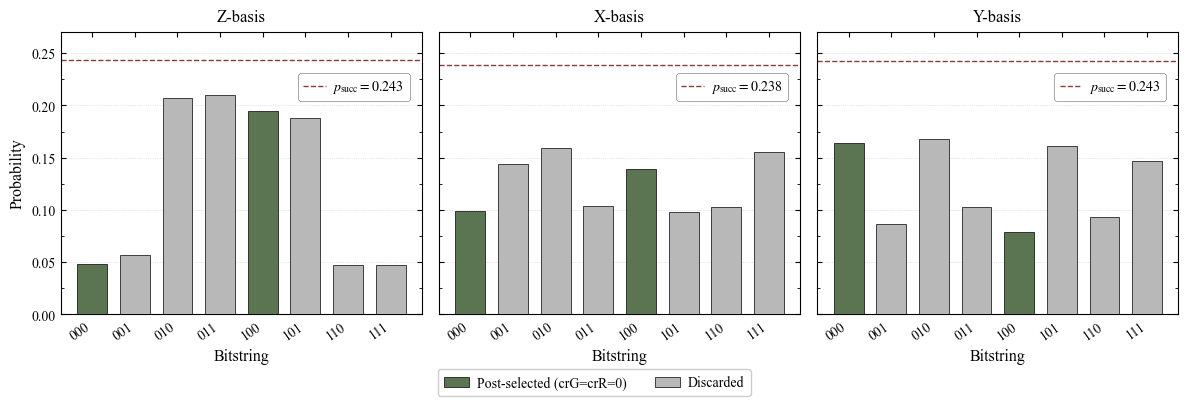

In [16]:
"""
PRX-style 3-panel figure: raw measurement histograms for ibm_torino,
one panel per tomography basis (Z, X, Y).  Post-selected bitstrings
(crG=crR=0) are highlighted in green; discarded outcomes are grey.

Run:
    python raw_counts_histograms.py

Outputs:
    raw_counts_histograms.png  (600 dpi)
    raw_counts_histograms.pdf  (vector, for LaTeX)
"""
import json
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.font_manager as fm
import numpy as np
from matplotlib.ticker import MultipleLocator

# ============================================================
# Tweakable parameters
# ============================================================
INPUT_JSON   = "hardware_postselection_results.json"
OUT_BASE     = "/Users/nandan/Desktop/CTCs/IBM/raw_counts_histograms"

FIGSIZE_IN   = (12.0, 4.2)        # 3 panels side by side, comfortably wide

COLOR_KEPT   = "#5b7553"          # muted sage green (post-selected)
COLOR_DROP   = "#b8b8b8"          # neutral grey (discarded)
COLOR_PSUCC  = "#8c3b3b"          # muted brick red (p_succ reference line)

SHOW_SUPTITLE = False
SUPTITLE_TEXT = (r"Raw measurement histograms — ibm_torino  "
                 r"(green bars = post-selected Bell outcome $\,|\Phi^{+}\rangle$)")

# Bitstring is "crTomo|crG|crR" — post-select on crG=0, crR=0,
# i.e. the last two characters of the bitstring are '00'.
def is_postselected(bitstring):
    return bitstring[-2:] == "00"

# Canonical bitstring ordering (Z-basis natural)
ORDER = ["000", "001", "010", "011", "100", "101", "110", "111"]

# ============================================================
# Font selection
# ============================================================
installed = {f.name for f in fm.fontManager.ttflist}
if "Times New Roman" in installed:
    SERIF_STACK = ["Times New Roman"]
elif "Times" in installed:
    SERIF_STACK = ["Times"]
else:
    SERIF_STACK = ["STIX Two Text", "STIXGeneral", "DejaVu Serif"]

# ============================================================
# PRX rcParams
# ============================================================
mpl.rcParams.update({
    "font.family":         "serif",
    "font.serif":          SERIF_STACK,
    "mathtext.fontset":    "stix",
    "font.size":           10.5,
    "axes.labelsize":      11.5,
    "axes.titlesize":      12,
    "xtick.labelsize":     10,
    "ytick.labelsize":     10,
    "legend.fontsize":     10,
    "axes.linewidth":      0.8,
    "xtick.major.width":   0.8,
    "ytick.major.width":   0.8,
    "xtick.minor.width":   0.6,
    "ytick.minor.width":   0.6,
    "xtick.major.size":    3.5,
    "ytick.major.size":    3.5,
    "xtick.minor.size":    2.0,
    "ytick.minor.size":    2.0,
    "xtick.direction":     "in",
    "ytick.direction":     "in",
    "xtick.top":           True,
    "ytick.right":         True,
    "pdf.fonttype":        42,
    "ps.fonttype":         42,
})

# ============================================================
# Load data
# ============================================================
with open(INPUT_JSON) as f:
    data = json.load(f)

backend     = data["metadata"]["backend"]
shots       = data["metadata"]["shots_per_basis"]
raw         = data["raw_counts"]               # {Z, X, Y} -> {bitstring -> count}

# Per-basis post-selection probability:
# Sum of counts for post-selected bitstrings, divided by total shots.
def psucc_for_basis(counts):
    kept = sum(c for b, c in counts.items() if is_postselected(b))
    return kept / sum(counts.values())

# ============================================================
# Figure
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=FIGSIZE_IN, sharey=True)

BASIS_LABELS = [("Z", "Z-basis", axes[0]),
                ("X", "X-basis", axes[1]),
                ("Y", "Y-basis", axes[2])]

x_idx = np.arange(len(ORDER))

for basis, panel_title, ax in BASIS_LABELS:
    counts = raw[basis]
    total  = sum(counts.values())
    # Build the probability vector in canonical order; missing bitstrings → 0
    probs = np.array([counts.get(b, 0) / total for b in ORDER])
    colors = [COLOR_KEPT if is_postselected(b) else COLOR_DROP for b in ORDER]

    ax.bar(x_idx, probs, width=0.7,
           color=colors, edgecolor="black", linewidth=0.5,
           zorder=3)

    # p_succ reference line
    p_succ_basis = psucc_for_basis(counts)
    ax.axhline(p_succ_basis, color=COLOR_PSUCC,
               linewidth=1.0, linestyle="--", zorder=2,
               label=rf"$p_{{\mathrm{{succ}}}}={p_succ_basis:.3f}$")

    # Title, ticks, labels
    ax.set_title(f"{panel_title}", pad=8)
    ax.set_xticks(x_idx)
    ax.set_xticklabels(ORDER, rotation=35, ha="right")
    ax.set_xlabel(r"Bitstring")
    ax.set_ylim(0, 0.27)
    ax.yaxis.set_major_locator(MultipleLocator(0.05))
    ax.yaxis.set_minor_locator(MultipleLocator(0.025))
    ax.yaxis.grid(True, which="major", linestyle=":", linewidth=0.5,
                  color="grey", alpha=0.4, zorder=0)
    ax.set_axisbelow(True)
    leg = ax.legend(loc="upper right", bbox_to_anchor=(0.985, 0.88),
                    frameon=True, framealpha=0.95,
                    handlelength=1.6, handletextpad=0.5, borderpad=0.4)
    leg.get_frame().set_linewidth(0.5); leg.get_frame().set_edgecolor("0.5")

axes[0].set_ylabel("Probability")

# Common legend for the bar colours, below the panels
kept_patch = mpatches.Patch(facecolor=COLOR_KEPT, edgecolor="black",
                            linewidth=0.5, label="Post-selected (crG=crR=0)")
drop_patch = mpatches.Patch(facecolor=COLOR_DROP, edgecolor="black",
                            linewidth=0.5, label="Discarded")
fig.legend(handles=[kept_patch, drop_patch],
           loc="lower center", ncol=2, frameon=True, framealpha=0.95,
           bbox_to_anchor=(0.5, -0.005),
           handlelength=1.8, handletextpad=0.6, columnspacing=2.0,
           borderpad=0.45)

# Suptitle
if SHOW_SUPTITLE:
    fig.suptitle(SUPTITLE_TEXT, fontsize=12.5, y=1.00)

plt.tight_layout(rect=[0, 0.05, 1, 0.97])

# ============================================================
# Save
# ============================================================
fig.savefig(f"{OUT_BASE}.png", dpi=600, bbox_inches="tight")
fig.savefig(f"{OUT_BASE}.pdf",            bbox_inches="tight")
print("Font in use:", mpl.rcParams["font.serif"][0])
print(f"Saved: {OUT_BASE}.png")
print(f"Saved: {OUT_BASE}.pdf")

Font in use: Times New Roman
Saved: /Users/nandan/Desktop/CTCs/IBM/postselection_rate.png
Saved: /Users/nandan/Desktop/CTCs/IBM/postselection_rate.pdf


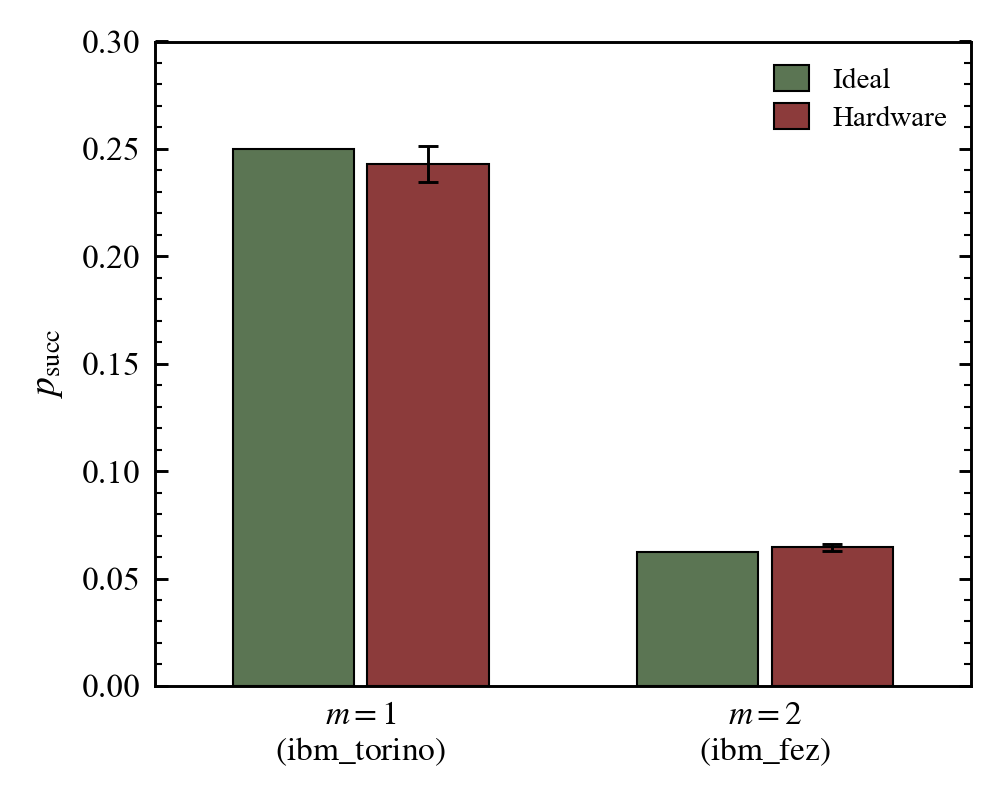

In [2]:
"""
PRL single-column bar chart: post-selection probability — Ideal vs Hardware,
for the 1-qubit and 2-qubit CTC protocols.

Two grouped clusters on the x-axis:
    Cluster 1 (1-qubit, m=1):  Ideal = 1/4,  Hardware = ibm_torino
    Cluster 2 (2-qubit, m=2):  Ideal = 1/16, Hardware = ibm_fez

Each cluster has two bars (Ideal vs Hardware) with the hardware bar carrying
a Clopper–Pearson 95% CI error bar.

Run:
    python postselection_rate.py

Outputs:
    postselection_rate.png  (600 dpi, slides/previews)
    postselection_rate.pdf  (vector, for LaTeX/journal submission)

------------------------------------------------------------------
DATA SOURCES
------------------------------------------------------------------
Both JSONs must follow the same schema used by the 1-qubit run:
    data["p_succ"]["estimate"|"ci_lo"|"ci_hi"]
    data["metadata"]["backend"]

Set the file paths at the top.  If the 2-qubit JSON is missing,
the script falls back to plotting only the 1-qubit cluster.
"""
import json
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
from matplotlib.ticker import MultipleLocator
from matplotlib.patches import Patch

# ============================================================
# Tweakable parameters
# ============================================================
INPUT_JSON_1Q = "hardware_postselection_results.json"           # m = 1
INPUT_JSON_2Q = "hardware_postselection_results_2q.json"        # m = 2 (ibm_fez)
OUT_BASE      = "/Users/nandan/Desktop/CTCs/IBM/postselection_rate"

# Ideal post-selection probabilities: 1 / 4^m
P_IDEAL_1Q = 1.0 / 4.0      # 0.25
P_IDEAL_2Q = 1.0 / 16.0     # 0.0625

COLOR_IDEAL = "#5b7553"     # muted sage green
COLOR_HW    = "#8c3b3b"     # muted brick red

FIGSIZE_IN  = (3.375, 2.7)  # PRL single column = 3.375 in
BAR_WIDTH   = 0.36
GROUP_GAP   = 1.2           # x-distance between the two clusters

# ============================================================
# Font selection: real Times if available, else STIX Two Text
# ============================================================
installed = {f.name for f in fm.fontManager.ttflist}
if "Times New Roman" in installed:
    SERIF_STACK = ["Times New Roman"]
elif "Times" in installed:
    SERIF_STACK = ["Times"]
else:
    SERIF_STACK = ["STIX Two Text", "STIXGeneral", "DejaVu Serif"]
MATHTEXT_FS = "stix"

# ============================================================
# PRL-style rcParams
# ============================================================
mpl.rcParams.update({
    "font.family":         "serif",
    "font.serif":          SERIF_STACK,
    "mathtext.fontset":    MATHTEXT_FS,
    "font.size":           8,
    "axes.labelsize":      9,
    "axes.titlesize":      9,
    "xtick.labelsize":     8,
    "ytick.labelsize":     8,
    "legend.fontsize":     7,
    "axes.linewidth":      0.7,
    "xtick.major.width":   0.7,
    "ytick.major.width":   0.7,
    "xtick.minor.width":   0.5,
    "ytick.minor.width":   0.5,
    "xtick.major.size":    3.0,
    "ytick.major.size":    3.0,
    "xtick.minor.size":    1.6,
    "ytick.minor.size":    1.6,
    "xtick.direction":     "in",
    "ytick.direction":     "in",
    "xtick.top":           True,
    "ytick.right":         True,
    "axes.spines.top":     True,
    "axes.spines.right":   True,
    "pdf.fonttype":        42,
    "ps.fonttype":         42,
})

# ============================================================
# Loader
# ============================================================
def load_psucc(path):
    """Return (p_hw, ci_lo, ci_hi, backend). Returns None if file missing."""
    if not os.path.exists(path):
        return None
    with open(path) as f:
        data = json.load(f)
    return (
        data["p_succ"]["estimate"],
        data["p_succ"]["ci_lo"],
        data["p_succ"]["ci_hi"],
        data["metadata"]["backend"],
    )

d1 = load_psucc(INPUT_JSON_1Q)
d2 = load_psucc(INPUT_JSON_2Q)

if d1 is None:
    raise FileNotFoundError(f"1-qubit JSON not found: {INPUT_JSON_1Q}")

p_hw_1, lo_1, hi_1, backend_1 = d1

if d2 is not None:
    p_hw_2, lo_2, hi_2, backend_2 = d2
    have_2q = True
else:
    print(f"[warn] {INPUT_JSON_2Q} not found — plotting only the 1-qubit cluster.")
    have_2q = False

# ============================================================
# Geometry: two clusters of two bars each
# ============================================================
# Cluster centers
# Render backend names inside \mathrm so they go through the same mathtext
# path as "$m=1$" — this guarantees consistent typography regardless of which
# serif font matplotlib actually resolved (Times New Roman, Times, or STIX Two
# Text fallback). The underscore in "ibm_fez" must be escaped for mathtext.
def _mathrm(name: str) -> str:
    return r"\mathrm{" + name.replace("_", r"\_") + r"}"

if have_2q:
    centers = np.array([0.0, GROUP_GAP])
    cluster_labels = [
        f"$m=1$\n$({_mathrm(backend_1)})$",
        f"$m=2$\n$({_mathrm(backend_2)})$",
    ]
else:
    centers = np.array([0.0])
    cluster_labels = [f"$m=1$\n$({_mathrm(backend_1)})$"]

# Within each cluster: ideal at center - w/2, hardware at center + w/2
off = BAR_WIDTH / 2 + 0.02

ideal_x = centers - off
hw_x    = centers + off

ideal_vals = [P_IDEAL_1Q] + ([P_IDEAL_2Q] if have_2q else [])
hw_vals    = [p_hw_1]     + ([p_hw_2]     if have_2q else [])
hw_lo      = [lo_1]       + ([lo_2]       if have_2q else [])
hw_hi      = [hi_1]       + ([hi_2]       if have_2q else [])

yerr_hw = np.array([
    [hw_vals[i] - hw_lo[i] for i in range(len(hw_vals))],
    [hw_hi[i] - hw_vals[i] for i in range(len(hw_vals))],
])

# ============================================================
# Figure
# ============================================================
fig, ax = plt.subplots(figsize=FIGSIZE_IN, dpi=300)

ax.bar(
    ideal_x, ideal_vals,
    width=BAR_WIDTH,
    color=COLOR_IDEAL, edgecolor="black", linewidth=0.5,
    zorder=3, label="Ideal",
)
ax.bar(
    hw_x, hw_vals,
    width=BAR_WIDTH,
    color=COLOR_HW, edgecolor="black", linewidth=0.5,
    zorder=3, label="Hardware",
)

# 95% Clopper-Pearson CIs on hardware bars
ax.errorbar(
    hw_x, hw_vals, yerr=yerr_hw,
    fmt="none", ecolor="black",
    elinewidth=0.7, capsize=2.5, capthick=0.7,
    zorder=4,
)

# ---- axes formatting ----
ax.set_xticks(centers)
ax.set_xticklabels(cluster_labels)
ax.tick_params(axis="x", which="both", length=0)
ax.set_ylabel(r"$p_{\mathrm{succ}}$", labelpad=4)

# y-limit: leave headroom above the largest bar+CI
ymax_data = max(max(ideal_vals), max(hi for hi in hw_hi))
ax.set_ylim(0, max(0.30, 1.15 * ymax_data))
ax.yaxis.set_major_locator(MultipleLocator(0.05))
ax.yaxis.set_minor_locator(MultipleLocator(0.01))

# Pad x-limits so the clusters don't sit flush with the frame
xpad = BAR_WIDTH + 0.25
ax.set_xlim(centers[0] - xpad, centers[-1] + xpad)

# Legend: clean Ideal/Hardware key
legend_handles = [
    Patch(facecolor=COLOR_IDEAL, edgecolor="black", linewidth=0.5, label="Ideal"),
    Patch(facecolor=COLOR_HW,    edgecolor="black", linewidth=0.5, label="Hardware"),
]
ax.legend(
    handles=legend_handles,
    loc="upper right", frameon=False, handlelength=1.2, handleheight=1.0,
    borderpad=0.3, labelspacing=0.3,
)

plt.tight_layout()

# ============================================================
# Save
# ============================================================
plt.savefig(f"{OUT_BASE}.png", dpi=600, bbox_inches="tight")
plt.savefig(f"{OUT_BASE}.pdf",            bbox_inches="tight")
print("Font in use:", mpl.rcParams["font.serif"][0])
print(f"Saved: {OUT_BASE}.png")
print(f"Saved: {OUT_BASE}.pdf")